In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
completing_deltas = np.load("completing_deltas.npy")

In [3]:
completing_deltas

array([0.15756773, 0.16152563, 0.15680422, 0.15103175, 0.12908699,
       0.1045053 , 0.08577038, 0.07375268, 0.00154555, 0.00216948,
       0.00217842])

In [4]:
disrupting_deltas = np.load("disrupting_deltas.npy")

In [5]:
disrupting_deltas

array([-0.00501396, -0.00145119, -0.00569647, -0.01021237, -0.02924253,
       -0.05341162, -0.07216404,  0.00153679, -0.00077721,  0.00224305,
        0.00183792])

In [6]:
x = np.linspace(0, 1, 11)

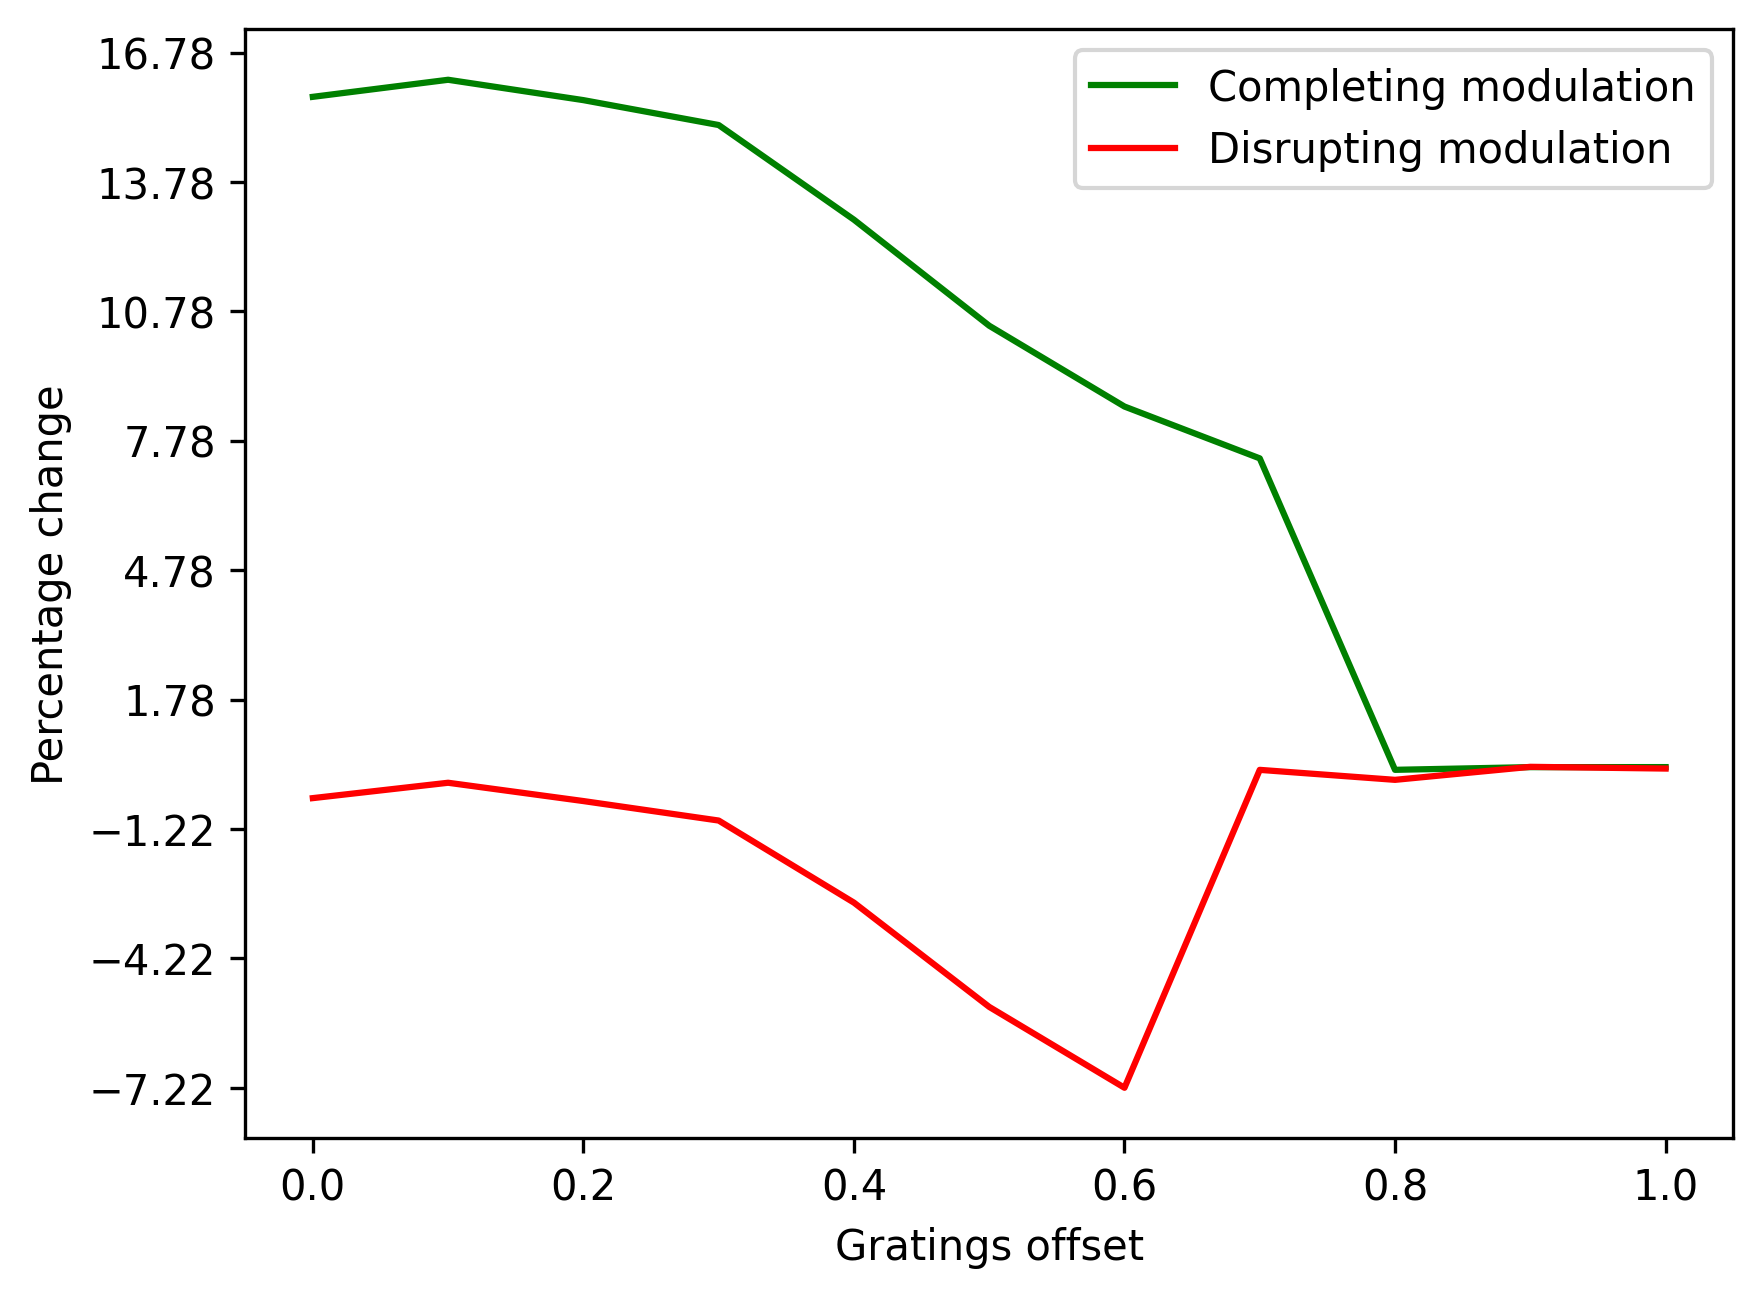

In [7]:
fig, ax = plt.subplots(dpi=300)
ax.plot(x, completing_deltas*100, label="Completing modulation", color="green")
ax.plot(x, disrupting_deltas*100, label="Disrupting modulation", color="red")
ax.set_xlabel("Gratings offset")
ax.set_ylabel("Percentage change")
ax.set_yticks(np.arange(np.min(disrupting_deltas*100), np.max(completing_deltas*100)+1, 3))
ax.legend()

In [8]:
from pathlib import Path
import joblib
from insilico_stimuli.stimuli import GaborSet, CenterSurround
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from models.hierarchical_grating_model import HierarchicalGratingModel
from sklearn.metrics.pairwise import cosine_similarity

canvas_size                = [36, 36]
locations                  = [[18, 18]]  # center position
sizes_total                = [36]          # total size (center + surround)
sizes_center               = [0.5]           # portion of radius used for center circle
sizes_surround             = [0.5]      # defines the starting portion of radius for surround
contrasts_center           = [1.0]     # try 2 center contrasts
contrasts_surround         = [1.0]          # surround contrast
orientations_center        = [0.0, np.pi/2, np.pi/4]  # variable orientation
orientations_surround      = [0.0, np.pi/2, np.pi/4]  # center only
spatial_frequencies_center = [0.2]           # fixed spatial frequency
phases_center              = [np.pi]  # center phases 
grey_levels                = [0.0]           # fixed grey level
# spatial_frequencies_surround = [0.1, 0.3]  # optional parameter, default: same as spatial_frequencies_center
# phases_surround = [np.pi/4]                # optional parameter, default: same as phases_center

center_surround = CenterSurround(canvas_size=canvas_size, 
        locations=locations,
        sizes_total=sizes_total,
        sizes_center=sizes_center,
        sizes_surround=sizes_surround,
        contrasts_center=contrasts_center,
        contrasts_surround=contrasts_surround,
        orientations_center=orientations_center,
        orientations_surround=orientations_surround,
        spatial_frequencies_center=spatial_frequencies_center,
        phases_center=phases_center,
        grey_levels=grey_levels
)

# gratings_offset = 0.5
gratings = np.array([center_surround.images()[idx] for idx in range(len(center_surround.images())) if center_surround.params_dict_from_idx(idx)['orientation_center'] == center_surround.params_dict_from_idx(idx)['orientation_surround']])

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [9]:
first_grating = gratings[0]
second_grating = gratings[1]

In [10]:
similarities = []
for offset in x:
    noised_first = first_grating + offset
    noised_second = second_grating + offset
    similarities.append((cosine_similarity(noised_first, noised_second).mean()))

In [11]:
similarities

[-0.0052742765290714625,
 -0.02833959979773922,
 -0.049848557281171574,
 -0.06893981192626206,
 0.3125652322631347,
 0.3622755850588597,
 0.4029382426003719,
 0.4359333320030704,
 0.46265258457631675,
 0.4843343615460129,
 0.6617413068397182]

Text(0, 0.5, 'Cosine similarity')

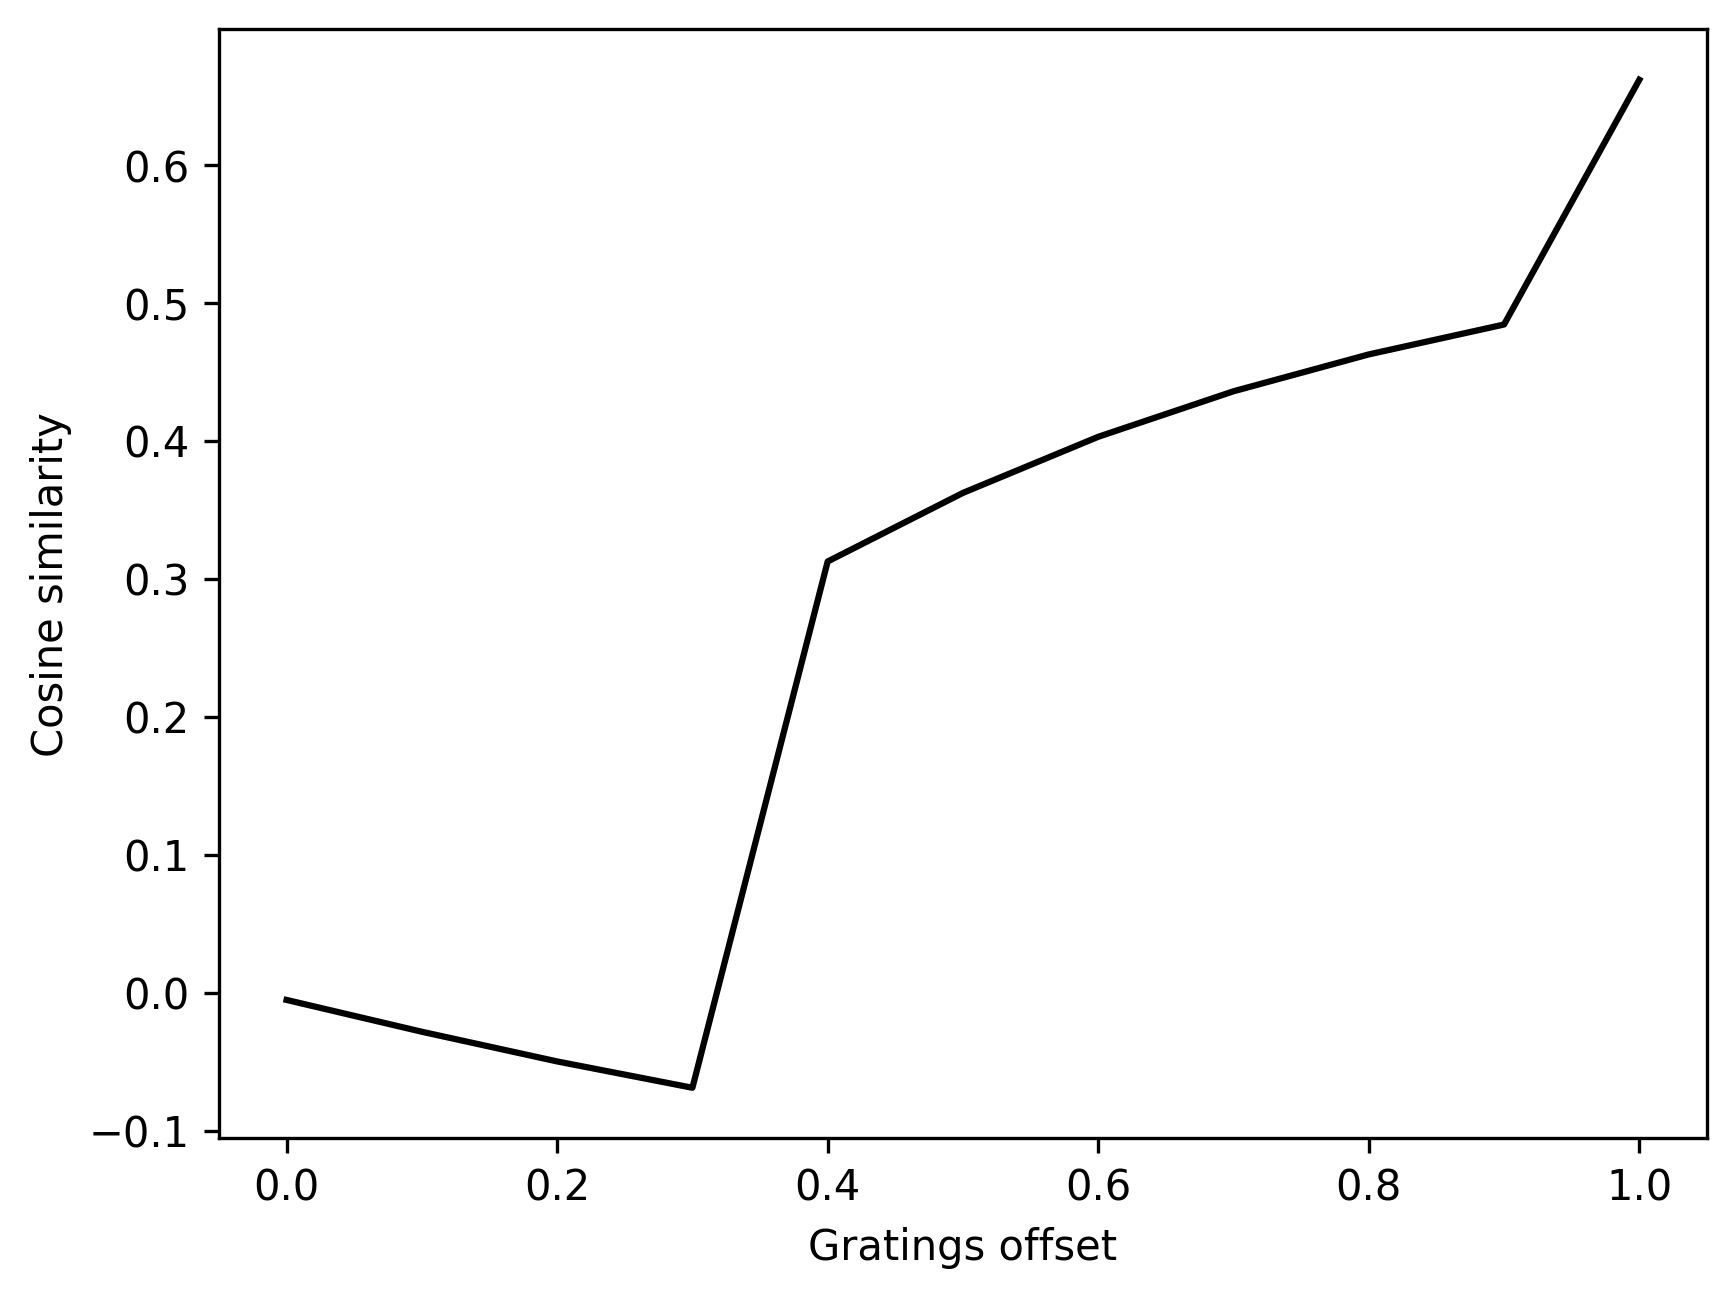

In [12]:
fig, ax = plt.subplots(dpi=300)
ax.plot(x, similarities, color="black")
ax.set_xlabel("Gratings offset")
ax.set_ylabel("Cosine similarity")

(-0.5, 35.5, 35.5, -0.5)

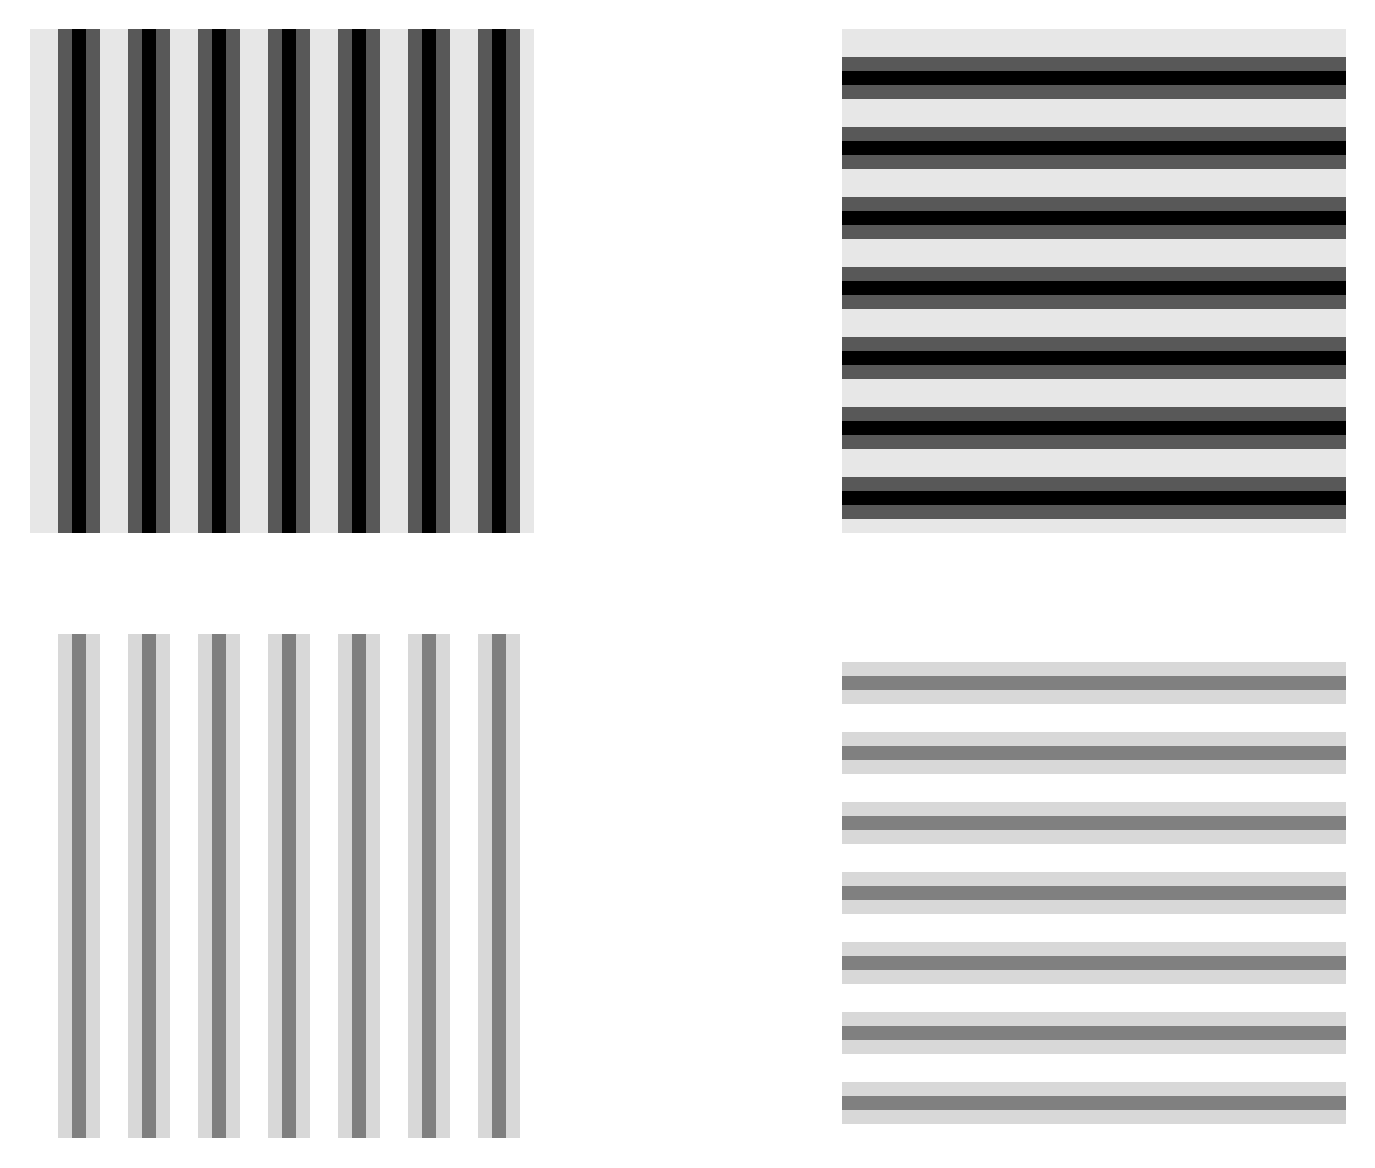

In [13]:
fig, axs = plt.subplots(2, 2, dpi=300)
axs[0][0].imshow(first_grating, cmap="gray", vmin=-1, vmax=1)
axs[0][0].axis("off")
axs[0][1].imshow(second_grating, cmap="gray", vmin=-1, vmax=1)
axs[0][1].axis("off")
axs[1][0].imshow(noised_first, cmap="gray", vmin=-1, vmax=1)
axs[1][0].axis("off")
axs[1][1].imshow(noised_second, cmap="gray", vmin=-1, vmax=1)
axs[1][1].axis("off")

In [14]:
np.min(gratings[0]), np.max(gratings[0])

(-1.0, 0.8090169943749492)

In [15]:
np.min(noised_first), np.max(noised_first)

(0.0, 1.8090169943749492)

In [16]:
1. check with the real numbers
2. 10 chains with 1000 samples each and then variability across chains
3. zero reference line
4. look at the cosine similarity
5. grating offsets smaller


SyntaxError: invalid syntax (4225502039.py, line 1)